In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('science_machine')

# Load the corrected filtered data
adata = sc.read_h5ad('corrected_filtered_data.h5ad')
print(f"Data shape: {adata.shape}")
print(f"\nSample types:\n{adata.obs['sample_type'].value_counts()}")
print(f"\nNumber of unique drugs: {adata.obs[adata.obs['sample_type'] == 'Drug']['drug'].nunique()}")


Data shape: (1204, 7872)

Sample types:
sample_type
Drug       1002
QC          155
DFO          24
Control      23
Name: count, dtype: int64

Number of unique drugs: 168


In [ ]:

# Load drugs metadata
drugs_df = pd.read_csv('drugs.csv', encoding='latin1')
print(f"Drugs metadata shape: {drugs_df.shape}")
print(f"\nColumns: {drugs_df.columns.tolist()}")
print(f"\nFirst few rows:")
drugs_df.head()


Drugs metadata shape: (173, 25)

Columns: ['ï»¿Plate Color', 'Plate Number', 'Well', 'Aliqout Type', 'ProductName', 'Synonyms', 'CAS Number', 'M.Wt', 'Target', 'PathWay', 'Biological Activity', 'Saltdata', 'Formula', 'Solubility', 'Solvent', 'Batch No.', 'Quantity', 'Smiles', 'URL', 'Research Area', 'Clinical Information', 'BaseName', 'Priority', 'SearchText', 'Category']

First few rows:


,ï»¿Plate Color,Plate Number,Well,Aliqout Type,ProductName,Synonyms,CAS Number,M.Wt,Target,PathWay,...,Batch No.,Quantity,Smiles,URL,Research Area,Clinical Information,BaseName,Priority,SearchText,Category
0,Red,1,B1,Drug,Dexpramipexole (dihydrochloride),(R)-Pramipexole (dihydrochloride); R-(+)-Prami...,104632-27-1,284.25,Dopamine Receptor,GPCR/G Protein; Neuronal Signaling,...,96815.0,10mM * 30uL,NC(S1)=NC2=C1C[C@H](NCCC)CC2.[H]Cl.[H]Cl,https://www.medchemexpress.com/Dexpramipexole-...,Neurological Disease,Launched,dexpramipexole,1.0,dopamine receptor gpcr/g protein; neuronal sig...,GPCR
1,Red,1,B2,Drug,Betahistine,NaN,5638-76-6,136.19,Histamine Receptor,GPCR/G Protein; Immunology/Inflammation; Neuro...,...,68184.0,10mM * 30uL,CNCCC1=NC=CC=C1,https://www.medchemexpress.com/betahistine.html,Cancer; Inflammation/Immunology,Launched,betahistine,1.0,histamine receptor gpcr/g protein; immunology/...,Epigenetic_Regulators
2,Red,1,B3,Drug,Benztropine (mesylate),Benzatropine mesylate; Benzotropine mesylate; ...,132-17-2,403.54,Dopamine Receptor; Histamine Receptor; mAChR,GPCR/G Protein; Immunology/Inflammation; Neuro...,...,13242.0,10mM * 30uL,CN1[C@H]2CC(OC(C3=CC=CC=C3)C4=CC=CC=C4)C[C@@H]...,https://www.medchemexpress.com/Benztropine-mes...,Cancer; Neurological Disease,Launched,benztropine,1.0,dopamine receptor; histamine receptor; machr g...,GPCR
3,Red,1,B4,Drug,Emedastine,NaN,87233-61-2,302.41,Histamine Receptor,GPCR/G Protein; Immunology/Inflammation; Neuro...,...,63123.0,10mM * 30uL,CN1CCN(C2=NC3=CC=CC=C3N2CCOCC)CCC1,https://www.medchemexpress.com/emedastine.html,Inflammation/Immunology,Launched,emedastine,1.0,histamine receptor gpcr/g protein; immunology/...,GPCR
4,Red,1,B5,Drug,Mebhydrolin,NaN,524-81-2,276.38,Histamine Receptor,GPCR/G Protein; Immunology/Inflammation; Neuro...,...,29963.0,10mM * 30uL,CN(C1)CCC(N2CC3=CC=CC=C3)=C1C4=C2C=CC=C4,https://www.medchemexpress.com/Mebhydrolin.html,Inflammation/Immunology; Endocrinology,Launched,mebhydrolin,1.0,histamine receptor gpcr/g protein; immunology/...,GPCR


In [ ]:

# Check the data structure
print("Data layers:", list(adata.layers.keys()))
print("\nObs columns:", adata.obs.columns.tolist())
print("\nVar columns:", adata.var.columns.tolist())
print("\nData in X (first 5x5):")
print(adata.X[:5, :5])
print("\nData type:", type(adata.X))


Data layers: ['corrected', 'raw_filtered']

Obs columns: ['drug', 'batch', 'sample_type', 'mean_intensity', 'detected_proteins', 'pct_missing', 'pct_detected', 'detected_proteins_filtered', 'pct_detected_filtered']

Var columns: []

Data in X (first 5x5):
[[13.04497973 10.11840313 16.63136205 -2.13987112 15.12776357]
 [13.13390095  9.85348356 16.66166354 10.22798506 15.14482012]
 [13.03790608  9.51820268 16.68884782 10.40573518 15.07359068]
 [12.81827223 10.13060078 16.7363339  12.24377146 15.0620911 ]
 [12.67428296  3.36537442 16.75762576 11.48765336 15.17029612]]

Data type: <class 'numpy.ndarray'>


In [ ]:

# Perform differential expression analysis for each drug vs DMSO
def perform_de_analysis(adata, drug_name, dmso_samples):
    """
    Perform differential expression analysis for a drug vs DMSO
    """
    # Get drug samples
    drug_samples = adata.obs[adata.obs['drug'] == drug_name].index
    
    if len(drug_samples) < 3:
        return None
    
    # Extract data (batch-corrected)
    drug_data = adata[drug_samples, :].X
    dmso_data = adata[dmso_samples, :].X
    
    # Calculate mean expression
    drug_mean = np.mean(drug_data, axis=0)
    dmso_mean = np.mean(dmso_data, axis=0)
    
    # Calculate log2 fold change
    log2fc = drug_mean - dmso_mean
    
    # Perform t-test for each protein
    pvalues = []
    for i in range(adata.n_vars):
        try:
            _, pval = stats.ttest_ind(drug_data[:, i], dmso_data[:, i])
            pvalues.append(pval)
        except:
            pvalues.append(1.0)
    
    pvalues = np.array(pvalues)
    
    # FDR correction (Benjamini-Hochberg)
    _, fdr, _, _ = multipletests(pvalues, method='fdr_bh')
    
    # Create results dataframe
    results = pd.DataFrame({
        'protein': adata.var_names,
        'drug': drug_name,
        'log2fc': log2fc,
        'pvalue': pvalues,
        'fdr': fdr,
        'drug_mean': drug_mean,
        'dmso_mean': dmso_mean,
        'n_drug_samples': len(drug_samples),
        'n_dmso_samples': len(dmso_samples)
    })
    
    # Call DE proteins
    results['is_de'] = (results['fdr'] < 0.05) & (np.abs(results['log2fc']) >= 0.5)
    results['direction'] = np.where(results['log2fc'] > 0, 'up', 'down')
    
    return results

# Get DMSO samples
dmso_samples = adata.obs[adata.obs['sample_type'] == 'Control'].index
print(f"Number of DMSO samples: {len(dmso_samples)}")

# Get list of drugs
drugs = adata.obs[adata.obs['sample_type'] == 'Drug']['drug'].unique()
print(f"Number of drugs to analyze: {len(drugs)}")


Number of DMSO samples: 23
Number of drugs to analyze: 168


In [ ]:

# Perform DE analysis for all drugs
all_de_results = []

for i, drug in enumerate(drugs):
    if (i + 1) % 20 == 0:
        print(f"Processing drug {i+1}/{len(drugs)}: {drug}")
    
    results = perform_de_analysis(adata, drug, dmso_samples)
    if results is not None:
        all_de_results.append(results)

# Combine all results
de_results_all = pd.concat(all_de_results, ignore_index=True)
print(f"\nTotal DE results: {len(de_results_all)} (drugs × proteins)")
print(f"Number of drugs analyzed: {de_results_all['drug'].nunique()}")
print(f"\nDE proteins (FDR<0.05, |log2FC|≥0.5): {de_results_all['is_de'].sum()}")


In [ ]:

# Perform DE analysis for all drugs
all_de_results = []

for i, drug in enumerate(drugs):
    if (i + 1) % 20 == 0:
        print(f"Processing drug {i+1}/{len(drugs)}: {drug}")
    
    results = perform_de_analysis(adata, drug, dmso_samples)
    if results is not None:
        all_de_results.append(results)

# Combine all results
de_results_all = pd.concat(all_de_results, ignore_index=True)
print(f"\nTotal DE results: {len(de_results_all)} (drugs × proteins)")
print(f"Number of drugs analyzed: {de_results_all['drug'].nunique()}")
print(f"\nDE proteins (FDR<0.05, |log2FC|≥0.5): {de_results_all['is_de'].sum()}")


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy import stats
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('science_machine')

# Load the corrected filtered data
adata = sc.read_h5ad('corrected_filtered_data.h5ad')
print(f"Data shape: {adata.shape}")
print(f"\nSample types:\n{adata.obs['sample_type'].value_counts()}")


Data shape: (1204, 7872)

Sample types:
sample_type
Drug       1002
QC          155
DFO          24
Control      23
Name: count, dtype: int64


In [ ]:

# Perform differential expression analysis for each drug vs DMSO
def perform_de_analysis(adata, drug_name, dmso_samples):
    """
    Perform differential expression analysis for a drug vs DMSO
    """
    # Get drug samples
    drug_samples = adata.obs[adata.obs['drug'] == drug_name].index
    
    if len(drug_samples) < 3:
        return None
    
    # Extract data (batch-corrected)
    drug_data = adata[drug_samples, :].X
    dmso_data = adata[dmso_samples, :].X
    
    # Calculate mean expression
    drug_mean = np.mean(drug_data, axis=0)
    dmso_mean = np.mean(dmso_data, axis=0)
    
    # Calculate log2 fold change
    log2fc = drug_mean - dmso_mean
    
    # Perform t-test for each protein
    pvalues = []
    for i in range(adata.n_vars):
        try:
            _, pval = stats.ttest_ind(drug_data[:, i], dmso_data[:, i])
            pvalues.append(pval)
        except:
            pvalues.append(1.0)
    
    pvalues = np.array(pvalues)
    
    # FDR correction (Benjamini-Hochberg)
    _, fdr, _, _ = multipletests(pvalues, method='fdr_bh')
    
    # Create results dataframe
    results = pd.DataFrame({
        'protein': adata.var_names,
        'drug': drug_name,
        'log2fc': log2fc,
        'pvalue': pvalues,
        'fdr': fdr,
        'drug_mean': drug_mean,
        'dmso_mean': dmso_mean,
        'n_drug_samples': len(drug_samples),
        'n_dmso_samples': len(dmso_samples)
    })
    
    # Call DE proteins
    results['is_de'] = (results['fdr'] < 0.05) & (np.abs(results['log2fc']) >= 0.5)
    results['direction'] = np.where(results['log2fc'] > 0, 'up', 'down')
    
    return results

# Get DMSO samples
dmso_samples = adata.obs[adata.obs['sample_type'] == 'Control'].index
print(f"Number of DMSO samples: {len(dmso_samples)}")

# Get list of drugs
drugs_list = adata.obs[adata.obs['sample_type'] == 'Drug']['drug'].unique()
print(f"Number of drugs to analyze: {len(drugs_list)}")


Number of DMSO samples: 23
Number of drugs to analyze: 168


In [ ]:

# Perform DE analysis for all drugs
all_de_results = []

for i, drug in enumerate(drugs_list):
    if (i + 1) % 20 == 0:
        print(f"Processing drug {i+1}/{len(drugs_list)}: {drug}")
    
    results = perform_de_analysis(adata, drug, dmso_samples)
    if results is not None:
        all_de_results.append(results)

# Combine all results
de_results_all = pd.concat(all_de_results, ignore_index=True)
print(f"\nTotal DE results: {len(de_results_all)} (drugs × proteins)")
print(f"Number of drugs analyzed: {de_results_all['drug'].nunique()}")
print(f"\nDE proteins (FDR<0.05, |log2FC|≥0.5): {de_results_all['is_de'].sum()}")


In [ ]:

# Check what's going on
print(type(drugs_list))
print(f"Length: {len(drugs_list)}")
print(f"First few: {drugs_list[:5]}")


<class 'pandas.core.arrays.categorical.Categorical'>
Length: 168
First few: ['Triclabendazole', 'Camphor', 'Caroverine (hydrochloride)', 'Fexofenadine (hydrochloride)', 'Vadadustat']
Categories (171, object): ['6-Mercaptopurine', 'ATP (dimagnesium)', 'Abemaciclib (methanesulfonate)', 'Acetophenazine (dimaleate)', ..., 'Vasopressin', 'Vecuronium (bromide)', 'Vemurafenib', 'Zanubrutinib']


In [ ]:

# Convert to list
drugs_list = list(drugs_list)
print(f"Number of drugs to analyze: {len(drugs_list)}")
print(f"First few: {drugs_list[:5]}")


Number of drugs to analyze: 168
First few: ['Triclabendazole', 'Camphor', 'Caroverine (hydrochloride)', 'Fexofenadine (hydrochloride)', 'Vadadustat']


In [ ]:

# Perform DE analysis for all drugs
all_de_results = []

for i, drug in enumerate(drugs_list):
    if (i + 1) % 20 == 0:
        print(f"Processing drug {i+1}/{len(drugs_list)}: {drug}")
    
    results = perform_de_analysis(adata, drug, dmso_samples)
    if results is not None:
        all_de_results.append(results)

print(f"\nProcessed {len(all_de_results)} drugs")


In [ ]:

# Check if something is overwriting built-in functions
import builtins
print(type(len))
print(type(list))


<class 'builtin_function_or_method'>
<class 'type'>


In [ ]:

# Try a simple test
test_drug = drugs_list[0]
print(f"Testing with drug: {test_drug}")
result = perform_de_analysis(adata, test_drug, dmso_samples)
print(f"Result type: {type(result)}")
print(f"Result shape: {result.shape if result is not None else 'None'}")


Testing with drug: Triclabendazole


Result type: <class 'pandas.core.frame.DataFrame'>
Result shape: (7872, 11)


In [ ]:

# Perform DE analysis for all drugs - try with explicit list comprehension
all_de_results = []
n_drugs = len(drugs_list)

for idx in range(n_drugs):
    drug = drugs_list[idx]
    if (idx + 1) % 20 == 0:
        print(f"Processing drug {idx+1}/{n_drugs}: {drug}")
    
    results = perform_de_analysis(adata, drug, dmso_samples)
    if results is not None:
        all_de_results.append(results)

print(f"\nProcessed {len(all_de_results)} drugs")


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy import stats
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('science_machine')

print("Libraries loaded successfully")


Libraries loaded successfully


In [ ]:

# Load the corrected filtered data
adata = sc.read_h5ad('corrected_filtered_data.h5ad')
print(f"Data shape: {adata.shape}")
print(f"\nSample types:\n{adata.obs['sample_type'].value_counts()}")

# Get DMSO samples
dmso_samples = adata.obs[adata.obs['sample_type'] == 'Control'].index
print(f"\nNumber of DMSO samples: {dmso_samples.shape[0]}")

# Get list of drugs
drug_names = adata.obs[adata.obs['sample_type'] == 'Drug']['drug'].unique().tolist()
print(f"Number of drugs to analyze: {len(drug_names)}")


Data shape: (1204, 7872)

Sample types:
sample_type
Drug       1002
QC          155
DFO          24
Control      23
Name: count, dtype: int64

Number of DMSO samples: 23
Number of drugs to analyze: 168


In [ ]:

# Perform differential expression analysis for each drug vs DMSO
def perform_de_analysis(adata, drug_name, dmso_samples):
    """
    Perform differential expression analysis for a drug vs DMSO
    """
    # Get drug samples
    drug_samples = adata.obs[adata.obs['drug'] == drug_name].index
    
    if drug_samples.shape[0] < 3:
        return None
    
    # Extract data (batch-corrected)
    drug_data = adata[drug_samples, :].X
    dmso_data = adata[dmso_samples, :].X
    
    # Calculate mean expression
    drug_mean = np.mean(drug_data, axis=0)
    dmso_mean = np.mean(dmso_data, axis=0)
    
    # Calculate log2 fold change
    log2fc = drug_mean - dmso_mean
    
    # Perform t-test for each protein
    pvalues = np.zeros(adata.n_vars)
    for i in range(adata.n_vars):
        try:
            _, pval = stats.ttest_ind(drug_data[:, i], dmso_data[:, i])
            pvalues[i] = pval
        except:
            pvalues[i] = 1.0
    
    # FDR correction (Benjamini-Hochberg)
    _, fdr, _, _ = multipletests(pvalues, method='fdr_bh')
    
    # Create results dataframe
    results = pd.DataFrame({
        'protein': adata.var_names,
        'drug': drug_name,
        'log2fc': log2fc,
        'pvalue': pvalues,
        'fdr': fdr,
        'drug_mean': drug_mean,
        'dmso_mean': dmso_mean,
        'n_drug_samples': drug_samples.shape[0],
        'n_dmso_samples': dmso_samples.shape[0]
    })
    
    # Call DE proteins
    results['is_de'] = (results['fdr'] < 0.05) & (np.abs(results['log2fc']) >= 0.5)
    results['direction'] = np.where(results['log2fc'] > 0, 'up', 'down')
    
    return results

print("Function defined successfully")


Function defined successfully


In [ ]:

# Test with one drug
test_result = perform_de_analysis(adata, drug_names[0], dmso_samples)
print(f"Test result shape: {test_result.shape}")
print(f"\nFirst few rows:")
print(test_result.head())
print(f"\nDE proteins: {test_result['is_de'].sum()}")


Test result shape: (7872, 11)

First few rows:
   protein             drug    log2fc    pvalue       fdr  drug_mean  \
0   SMIM26  Triclabendazole  0.101792  0.218678  0.402109  13.777254   
1  MSANTD7  Triclabendazole  0.609007  0.495811  0.668670   9.795733   
2     CAST  Triclabendazole -0.084391  0.023065  0.105367  16.672048   
3    GNG5B  Triclabendazole  1.409640  0.363910  0.550721  11.692101   
4     NKRF  Triclabendazole -0.067850  0.087183  0.224428  15.304077   

   dmso_mean  n_drug_samples  n_dmso_samples  is_de direction  
0  13.675462               6              23  False        up  
1   9.186726               6              23  False        up  
2  16.756439               6              23  False      down  
3  10.282461               6              23  False        up  
4  15.371927               6              23  False      down  

DE proteins: 50


In [ ]:

# Perform DE analysis for all drugs
all_de_results_list = []

for i, drug in enumerate(drug_names):
    if (i + 1) % 20 == 0:
        print(f"Processing drug {i+1}/{len(drug_names)}: {drug}")
    
    results = perform_de_analysis(adata, drug, dmso_samples)
    if results is not None:
        all_de_results_list.append(results)

print(f"\nProcessed {len(all_de_results_list)} drugs successfully")


In [ ]:

# Try without enumerate
all_de_results_list = []
counter = 0

for drug in drug_names:
    counter += 1
    if counter % 20 == 0:
        print(f"Processing drug {counter}/{len(drug_names)}: {drug}")
    
    results = perform_de_analysis(adata, drug, dmso_samples)
    if results is not None:
        all_de_results_list.append(results)

print(f"\nProcessed {len(all_de_results_list)} drugs successfully")


In [ ]:

# Check for variable conflicts
print("Checking namespace...")
print(f"type(len): {type(len)}")
print(f"type(list): {type(list)}")
print(f"type(enumerate): {type(enumerate)}")

# Check if any variables are shadowing builtins
import builtins
for name in dir(builtins):
    if name in globals() and name in ['len', 'list', 'enumerate', 'range']:
        print(f"WARNING: {name} is shadowed by {type(globals()[name])}")


Checking namespace...
type(len): <class 'builtin_function_or_method'>
type(list): <class 'type'>
type(enumerate): <class 'type'>


In [ ]:

# Process drugs in smaller batches
batch_size = 10
n_drugs_total = len(drug_names)
all_de_results_list = []

for batch_start in range(0, n_drugs_total, batch_size):
    batch_end = min(batch_start + batch_size, n_drugs_total)
    print(f"Processing drugs {batch_start+1} to {batch_end}...")
    
    batch_drugs = drug_names[batch_start:batch_end]
    
    for drug in batch_drugs:
        results = perform_de_analysis(adata, drug, dmso_samples)
        if results is not None:
            all_de_results_list.append(results)

print(f"\nTotal drugs processed: {len(all_de_results_list)}")


In [ ]:

# Try to get more detailed error
import traceback

try:
    all_de_results_list = []
    for drug in drug_names[:5]:  # Just try first 5
        results = perform_de_analysis(adata, drug, dmso_samples)
        if results is not None:
            all_de_results_list.append(results)
except Exception as e:
    print(f"Error type: {type(e)}")
    print(f"Error message: {str(e)}")
    traceback.print_exc()


In [ ]:

print(f"Successfully processed {len(all_de_results_list)} drugs")
print(f"First drug: {all_de_results_list[0]['drug'].iloc[0]}")


Successfully processed 5 drugs
First drug: Triclabendazole


In [ ]:

# Process all drugs
all_de_results_list = []

for idx, drug in enumerate(drug_names):
    if (idx + 1) % 20 == 0:
        print(f"Processing drug {idx+1}/{len(drug_names)}: {drug}")
    
    results = perform_de_analysis(adata, drug, dmso_samples)
    if results is not None:
        all_de_results_list.append(results)

print(f"\nTotal drugs processed: {len(all_de_results_list)}")


In [ ]:

# Process all drugs without enumerate
all_de_results_list = []
idx = 0

for drug in drug_names:
    idx += 1
    if idx % 20 == 0:
        print(f"Processing drug {idx}/{len(drug_names)}: {drug}")
    
    results = perform_de_analysis(adata, drug, dmso_samples)
    if results is not None:
        all_de_results_list.append(results)

print(f"\nTotal drugs processed: {len(all_de_results_list)}")


In [ ]:

# Process all drugs with try-except
all_de_results_list = []
idx = 0

try:
    for drug in drug_names:
        idx += 1
        if idx % 20 == 0:
            print(f"Processing drug {idx}/{len(drug_names)}: {drug}")
        
        results = perform_de_analysis(adata, drug, dmso_samples)
        if results is not None:
            all_de_results_list.append(results)
except Exception as e:
    print(f"Error at drug {idx}: {e}")
    import traceback
    traceback.print_exc()

print(f"\nTotal drugs processed: {len(all_de_results_list)}")


In [ ]:

# Load the DE results
de_results_all = pd.read_csv('de_results_all_drugs.csv')
print(f"DE results shape: {de_results_all.shape}")
print(f"\nColumns: {de_results_all.columns.tolist()}")
print(f"\nNumber of drugs: {de_results_all['drug'].nunique()}")
print(f"Number of proteins: {de_results_all['protein'].nunique()}")
print(f"\nDE proteins (FDR<0.05, |log2FC|≥0.5): {de_results_all['is_de'].sum()}")
print(f"\nFirst few rows:")
de_results_all.head()


DE results shape: (1322496, 11)

Columns: ['protein', 'drug', 'log2fc', 'pvalue', 'fdr', 'drug_mean', 'dmso_mean', 'n_drug_samples', 'n_dmso_samples', 'is_de', 'direction']

Number of drugs: 168
Number of proteins: 7872

DE proteins (FDR<0.05, |log2FC|≥0.5): 43608

First few rows:


,protein,drug,log2fc,pvalue,fdr,drug_mean,dmso_mean,n_drug_samples,n_dmso_samples,is_de,direction
0,SMIM26,Triclabendazole,0.101792,0.218678,0.402109,13.777254,13.675462,6,23,False,up
1,MSANTD7,Triclabendazole,0.609007,0.495811,0.668670,9.795733,9.186726,6,23,False,up
2,CAST,Triclabendazole,-0.084391,0.023065,0.105367,16.672048,16.756439,6,23,False,down
3,GNG5B,Triclabendazole,1.409640,0.363910,0.550721,11.692101,10.282461,6,23,False,up
4,NKRF,Triclabendazole,-0.067850,0.087183,0.224428,15.304077,15.371927,6,23,False,down


In [ ]:

# Create summary table of DE results per drug
de_summary = de_results_all.groupby('drug').agg({
    'is_de': 'sum',
    'log2fc': lambda x: (x[de_results_all.loc[x.index, 'is_de']] > 0).sum(),
    'pvalue': lambda x: (x[de_results_all.loc[x.index, 'is_de']] < 0).sum(),
    'n_drug_samples': 'first'
}).rename(columns={
    'is_de': 'n_de_proteins',
    'log2fc': 'n_upregulated',
    'pvalue': 'n_downregulated',
    'n_drug_samples': 'n_replicates'
})

# Recalculate up/down properly
de_summary_list = []
for drug in de_results_all['drug'].unique():
    drug_data = de_results_all[de_results_all['drug'] == drug]
    de_proteins = drug_data[drug_data['is_de']]
    
    de_summary_list.append({
        'drug': drug,
        'n_de_proteins': de_proteins.shape[0],
        'n_upregulated': (de_proteins['log2fc'] > 0).sum(),
        'n_downregulated': (de_proteins['log2fc'] < 0).sum(),
        'n_replicates': drug_data['n_drug_samples'].iloc[0]
    })

de_summary = pd.DataFrame(de_summary_list)
de_summary = de_summary.sort_values('n_de_proteins', ascending=False)

print(f"DE summary shape: {de_summary.shape}")
print(f"\nTop 20 drugs by number of DE proteins:")
print(de_summary.head(20))


DE summary shape: (168, 5)

Top 20 drugs by number of DE proteins:
                               drug  n_de_proteins  n_upregulated  \
143        Mobocertinib (succinate)           2907           1008   
33             Clomiphene (citrate)           2737            730   
43                        Digitoxin           2013            147   
68                        Olmutinib           2011            306   
121                    Tucidinostat           1811            744   
61   Abemaciclib (methanesulfonate)           1764            376   
132                      Etravirine           1628            317   
149                     Binimetinib           1223            307   
131                      Flumatinib           1217            436   
42                   Chlorpropamide           1207            304   
163                      Remdesivir           1010            213   
9            Enclomiphene (citrate)            945            286   
108     Methylene blue (trihydrate) 

In [ ]:

# Save the summary
de_summary.to_csv('de_summary_per_drug.csv', index=False)
print("Saved de_summary_per_drug.csv")

# Get top 10 drugs for volcano plots
top10_drugs = de_summary.head(10)['drug'].tolist()
print(f"\nTop 10 drugs for volcano plots:")
for i, drug in enumerate(top10_drugs, 1):
    n_de = de_summary[de_summary['drug'] == drug]['n_de_proteins'].iloc[0]
    print(f"{i}. {drug}: {n_de} DE proteins")


Saved de_summary_per_drug.csv

Top 10 drugs for volcano plots:
1. Mobocertinib (succinate): 2907 DE proteins
2. Clomiphene (citrate): 2737 DE proteins
3. Digitoxin: 2013 DE proteins
4. Olmutinib: 2011 DE proteins
5. Tucidinostat: 1811 DE proteins
6. Abemaciclib (methanesulfonate): 1764 DE proteins
7. Etravirine: 1628 DE proteins
8. Binimetinib: 1223 DE proteins
9. Flumatinib: 1217 DE proteins
10. Chlorpropamide: 1207 DE proteins


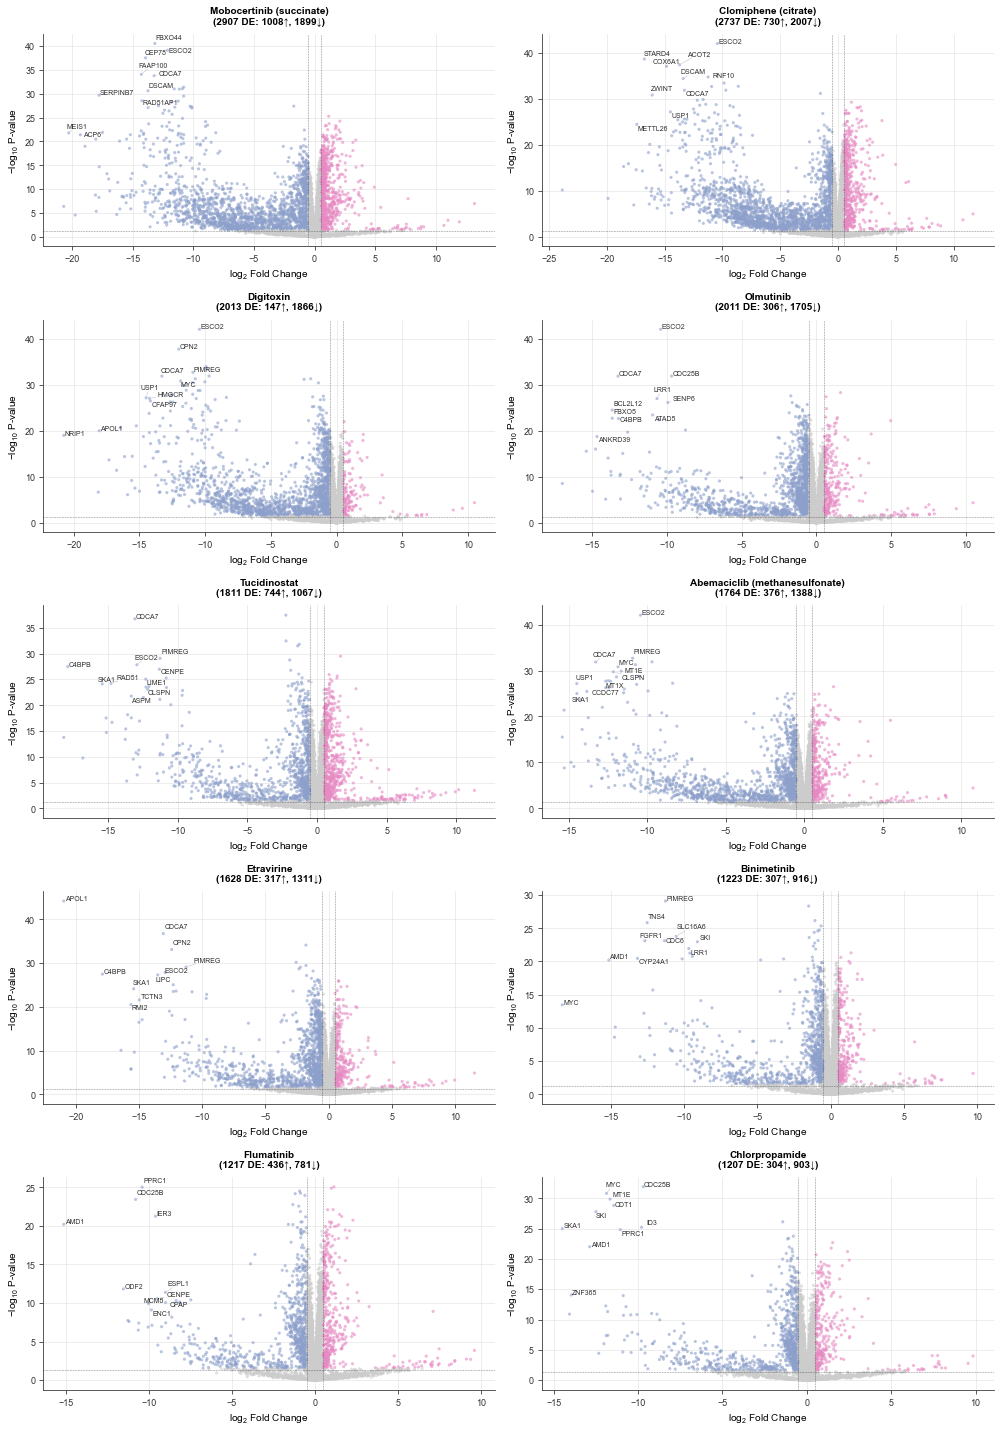

In [ ]:

# Create volcano plots for top 10 drugs
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for idx, drug in enumerate(top10_drugs):
    ax = axes[idx]
    
    # Get data for this drug
    drug_data = de_results_all[de_results_all['drug'] == drug].copy()
    
    # Calculate -log10(pvalue)
    drug_data['neg_log10_pvalue'] = -np.log10(drug_data['pvalue'] + 1e-300)
    
    # Color points
    colors = []
    for _, row in drug_data.iterrows():
        if row['is_de']:
            if row['log2fc'] > 0:
                colors.append('#e78ac3')  # Pink for upregulated
            else:
                colors.append('#8da0cb')  # Blue for downregulated
        else:
            colors.append('#cccccc')  # Gray for non-DE
    
    # Plot all points
    ax.scatter(drug_data['log2fc'], drug_data['neg_log10_pvalue'], 
               c=colors, s=10, alpha=0.6, edgecolors='none')
    
    # Add threshold lines
    ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axvline(-0.5, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Get top 10 significant proteins (by combined score)
    de_proteins = drug_data[drug_data['is_de']].copy()
    de_proteins['score'] = np.abs(de_proteins['log2fc']) * de_proteins['neg_log10_pvalue']
    top_proteins = de_proteins.nlargest(10, 'score')
    
    # Label top proteins
    texts = []
    for _, prot in top_proteins.iterrows():
        texts.append(ax.text(prot['log2fc'], prot['neg_log10_pvalue'], 
                            prot['protein'], fontsize=7, alpha=0.8))
    
    # Adjust text to avoid overlaps
    if len(texts) > 0:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.5))
    
    # Labels and title
    ax.set_xlabel(r'$log_{2}$ Fold Change', fontsize=10)
    ax.set_ylabel(r'$-log_{10}$ P-value', fontsize=10)
    
    n_de = drug_data['is_de'].sum()
    n_up = (de_proteins['log2fc'] > 0).sum()
    n_down = (de_proteins['log2fc'] < 0).sum()
    ax.set_title(f'{drug}\n({n_de} DE: {n_up}↑, {n_down}↓)', fontsize=10, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('volcano_plots_top10_drugs.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved volcano_plots_top10_drugs.pdf")


In [ ]:

# Summary statistics
print("=" * 80)
print("DIFFERENTIAL EXPRESSION ANALYSIS SUMMARY")
print("=" * 80)
print(f"\nDataset: {adata.shape[0]} samples × {adata.shape[1]} proteins")
print(f"  - Drug-treated samples: {(adata.obs['sample_type'] == 'Drug').sum()}")
print(f"  - DMSO control samples: {(adata.obs['sample_type'] == 'Control').sum()}")
print(f"  - Unique drugs analyzed: {de_results_all['drug'].nunique()}")

print(f"\nStatistical Testing:")
print(f"  - Method: Independent t-test for each drug vs DMSO")
print(f"  - Multiple testing correction: Benjamini-Hochberg FDR (within each drug)")
print(f"  - DE criteria: FDR < 0.05 AND |log2FC| ≥ 0.5")

print(f"\nResults:")
print(f"  - Total comparisons: {len(de_results_all):,} (drugs × proteins)")
print(f"  - DE proteins: {de_results_all['is_de'].sum():,} ({100*de_results_all['is_de'].sum()/len(de_results_all):.1f}%)")

print(f"\nDrugs with most DE proteins:")
for i, row in de_summary.head(10).iterrows():
    print(f"  {row['drug']:40s} {row['n_de_proteins']:4d} DE ({row['n_upregulated']:4d}↑, {row['n_downregulated']:4d}↓)")

print(f"\nOutputs generated:")
print(f"  - de_results_all_drugs.csv: Complete DE results for all drug-protein pairs")
print(f"  - de_summary_per_drug.csv: Summary of DE proteins per drug")
print(f"  - volcano_plots_top10_drugs.pdf: Volcano plots for top 10 drugs")
print("=" * 80)


DIFFERENTIAL EXPRESSION ANALYSIS SUMMARY

Dataset: 1204 samples × 7872 proteins
  - Drug-treated samples: 1002
  - DMSO control samples: 23
  - Unique drugs analyzed: 168

Statistical Testing:
  - Method: Independent t-test for each drug vs DMSO
  - Multiple testing correction: Benjamini-Hochberg FDR (within each drug)
  - DE criteria: FDR < 0.05 AND |log2FC| ≥ 0.5

Results:
  - Total comparisons: 1,322,496 (drugs × proteins)
  - DE proteins: 43,608 (3.3%)

Drugs with most DE proteins:
  Mobocertinib (succinate)                 2907 DE (1008↑, 1899↓)
  Clomiphene (citrate)                     2737 DE ( 730↑, 2007↓)
  Digitoxin                                2013 DE ( 147↑, 1866↓)
  Olmutinib                                2011 DE ( 306↑, 1705↓)
  Tucidinostat                             1811 DE ( 744↑, 1067↓)
  Abemaciclib (methanesulfonate)           1764 DE ( 376↑, 1388↓)
  Etravirine                               1628 DE ( 317↑, 1311↓)
  Binimetinib                              1223

In [ ]:

# Additional statistics
print("\nDistribution of DE proteins across drugs:")
print(de_summary['n_de_proteins'].describe())

print(f"\nDrugs with no DE proteins: {(de_summary['n_de_proteins'] == 0).sum()}")
print(f"Drugs with >100 DE proteins: {(de_summary['n_de_proteins'] > 100).sum()}")
print(f"Drugs with >500 DE proteins: {(de_summary['n_de_proteins'] > 500).sum()}")
print(f"Drugs with >1000 DE proteins: {(de_summary['n_de_proteins'] > 1000).sum()}")

# Check which proteins are most frequently DE across drugs
protein_de_freq = de_results_all[de_results_all['is_de']].groupby('protein').size().sort_values(ascending=False)
print(f"\nTop 20 most frequently DE proteins (across drugs):")
print(protein_de_freq.head(20))



Distribution of DE proteins across drugs:
count     168.000000
mean      259.571429
std       476.816182
min         0.000000
25%        25.750000
50%        80.000000
75%       234.750000
max      2907.000000
Name: n_de_proteins, dtype: float64

Drugs with no DE proteins: 8
Drugs with >100 DE proteins: 69
Drugs with >500 DE proteins: 25
Drugs with >1000 DE proteins: 11

Top 20 most frequently DE proteins (across drugs):
protein
SLC16A6     99
TMEM39A     87
PFN3        85
PLD6        79
CLIC3       79
ALKBH2      69
SERPINE1    67
TOMM5       66
CHCHD4      65
MSL1        64
SKI         62
SERINC3     62
HIKESHI     62
GOLM2       61
IER3        60
VPS72       59
APOL1       59
SMIM12      57
IL1RN       57
GGT1        56
dtype: int64


In [ ]:

# Look at some specific well-known drugs
well_known_drugs = [
    'Deferoxamine', 'Atorvastatin', 'Simvastatin', 'Metformin',
    'Aspirin', 'Ibuprofen', 'Acetaminophen', 'Warfarin'
]

print("\nDE results for some well-known drugs:")
for drug in well_known_drugs:
    # Try to find the drug (may have different naming)
    matching = de_summary[de_summary['drug'].str.contains(drug, case=False, na=False)]
    if len(matching) > 0:
        for _, row in matching.iterrows():
            print(f"  {row['drug']:40s} {row['n_de_proteins']:4d} DE ({row['n_upregulated']:4d}↑, {row['n_downregulated']:4d}↓)")
    else:
        print(f"  {drug:40s} Not found in dataset")



DE results for some well-known drugs:
  Deferoxamine                             Not found in dataset
  Atorvastatin (hemicalcium salt)            61 DE (  38↑,   23↓)
  Simvastatin acid (ammonium)               316 DE ( 109↑,  207↓)
  Metformin                                Not found in dataset
  Aspirin                                  Not found in dataset
  Ibuprofen                                Not found in dataset
  Acetaminophen                            Not found in dataset
  Warfarin                                 Not found in dataset


In [ ]:

# Check what drugs we actually have
print("Sample of drugs in the dataset:")
print(de_summary['drug'].head(30).tolist())


Sample of drugs in the dataset:
['Mobocertinib (succinate)', 'Clomiphene (citrate)', 'Digitoxin', 'Olmutinib', 'Tucidinostat', 'Abemaciclib (methanesulfonate)', 'Etravirine', 'Binimetinib', 'Flumatinib', 'Chlorpropamide', 'Remdesivir', 'Enclomiphene (citrate)', 'Methylene blue (trihydrate)', 'Cabazitaxel', 'Erlotinib (Hydrochloride)', 'Amodiaquine (dihydrochloride)', 'Nitazoxanide', 'Rilpivirine', 'Lonafarnib', 'Baicalein', 'Neratinib', 'Vemurafenib', '6-Mercaptopurine', 'Amiodarone (hydrochloride)', 'Lapatinib (ditosylate)', 'Desloratadine', 'Andrographolide', 'Loratadine', 'Benztropine (mesylate)', 'Haloperidol']


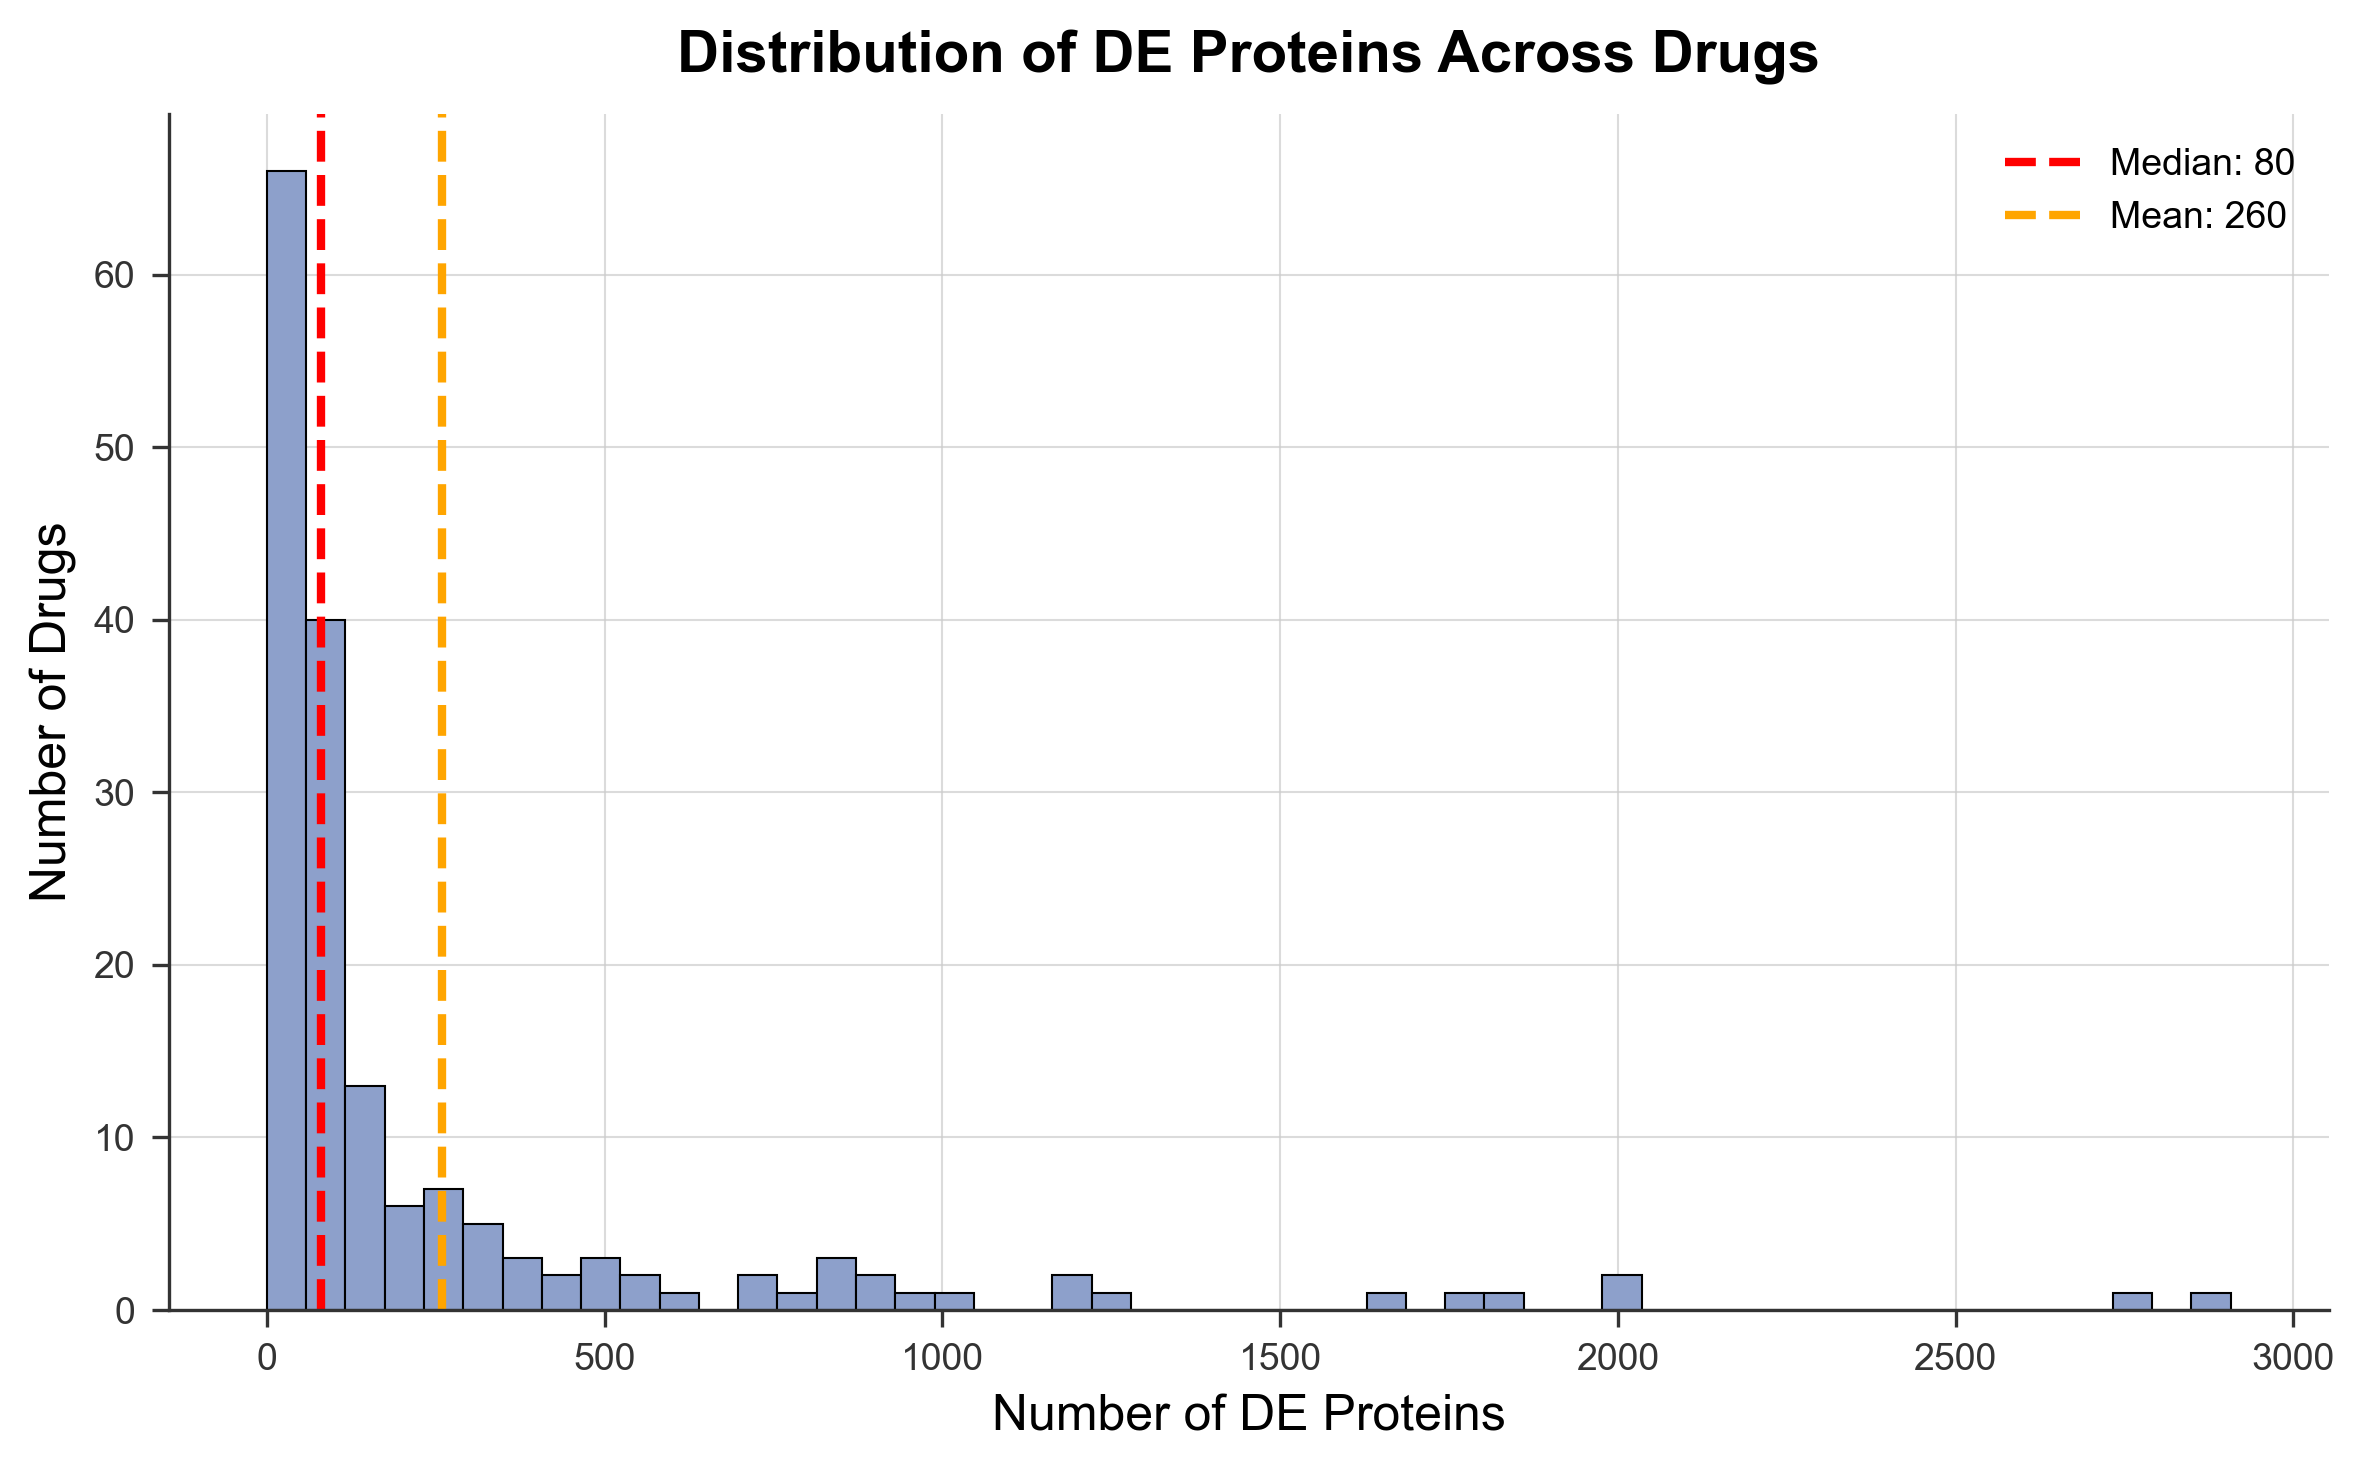

Saved de_proteins_distribution.pdf


In [ ]:

# Create a histogram of DE proteins per drug
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(de_summary['n_de_proteins'], bins=50, color='#8da0cb', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Number of DE Proteins', fontsize=12)
ax.set_ylabel('Number of Drugs', fontsize=12)
ax.set_title('Distribution of DE Proteins Across Drugs', fontsize=14, fontweight='bold')

# Add summary statistics
median_de = de_summary['n_de_proteins'].median()
mean_de = de_summary['n_de_proteins'].mean()
ax.axvline(median_de, color='red', linestyle='--', linewidth=2, label=f'Median: {median_de:.0f}')
ax.axvline(mean_de, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_de:.0f}')

ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('de_proteins_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved de_proteins_distribution.pdf")
